In [69]:
import pickle
import sklearn as sk
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [70]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

pandas    : 2.2.2
numpy     : 1.26.4
matplotlib: 3.9.2
sklearn   : 1.5.1
seaborn   : 0.13.2
xgboost   : 3.0.2



In [71]:
df = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/Projetos de Machine Learning/dados/manutencao.csv')

In [72]:
df.shape

(11500, 179)

In [73]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,VARIAVEL_ALVO
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,0
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,0
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,0
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,0


In [74]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,VARIAVEL_ALVO
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,0.200000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,0.400017
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,0.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,0.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,0.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,0.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,1.000000


In [75]:
df.isnull().sum().sum()

0

In [76]:
def calcula_prevalencia(y_actual):
    return sum(y_actual) / len(y_actual)

In [77]:
collist = df.columns.tolist()
cols_input = collist[0:178]
df = df[cols_input + ["VARIAVEL_ALVO"]]

In [78]:
dup_cols = set([x for x in cols_input if cols_input.count(x) > 1])
print(dup_cols)
assert len(dup_cols) == 0, 'há colunas duplicadas'

set()


In [79]:
print("Prevalencia da classe positiva: %.3f"% calcula_prevalencia(df['VARIAVEL_ALVO'].values))

Prevalencia da classe positiva: 0.200


In [80]:
df = df.sample(n = len(df))

In [81]:
df = df.reset_index(drop = True)

In [82]:
df_valid_teste = df.sample(frac = 0.3)
print('Tamanho de divisão de validação / teste: %.1f' % (len(df_valid_teste) / len(df)))

Tamanho de divisão de validação / teste: 0.3


In [83]:
df_teste = df_valid_teste.sample(frac = 0.5)

df_valid = df_valid_teste.drop(df_teste.index)

df_treino = df.drop(df_valid_teste.index)

In [84]:
print("Teste(n = %d): %.3f)" % (len(df_teste), calcula_prevalencia(df_teste.VARIAVEL_ALVO.values)))
print("Validação(n = %d): %.3f" % (len(df_valid), calcula_prevalencia(df_valid.VARIAVEL_ALVO.values)))
print("Treino(n = %d): %.3f)" % (len(df_treino), calcula_prevalencia(df_treino.VARIAVEL_ALVO.values)))

Teste(n = 1725): 0.176)
Validação(n = 1725): 0.206
Treino(n = 8050): 0.204)


In [85]:
print('Todas as amostras (n = %d)'%len(df))
assert len(df) == (len(df_teste) + len(df_valid) + len(df_treino)), 'algo saiu errado'

Todas as amostras (n = 11500)


In [86]:
rows_pos = df_treino.VARIAVEL_ALVO == 1

In [87]:
df_train_pos = df_treino.loc[rows_pos]
df_train_neg = df_treino.loc[~rows_pos]

In [88]:
n = np.min([len(df_train_pos), len(df_train_neg)])

In [89]:
df_treino_final = pd.concat([df_train_pos.sample(n = n, random_state = 64),
                             df_train_neg.sample(n = n, random_state = 64)],
                             axis = 0,
                             ignore_index = True)

In [90]:
df_treino_final = df_treino_final.sample(n = len(df_treino_final), random_state = 64).reset_index(drop = True)

In [91]:
print('Balanceamento em Treino(n = %d): %.3f'%(len(df_treino_final),
                                               calcula_prevalencia(df_treino_final.VARIAVEL_ALVO.values))) 

Balanceamento em Treino(n = 3282): 0.500


In [92]:
df_treino.to_csv('dados_treino.csv', index = False)
df_treino_final.to_csv('dados_treino_final.csv', index = False)
df_valid.to_csv('dados_valid.csv', index = False)
df_teste.to_csv('dados_teste.csv', index = False)

In [93]:
pickle.dump(cols_input, open('cols_input.sav', 'wb'))

In [94]:
X_treino = df_treino_final[cols_input].values
X_valid = df_valid[cols_input].values

In [95]:
y_treino = df_treino_final['VARIAVEL_ALVO'].values
y_valid = df_valid['VARIAVEL_ALVO'].values

In [96]:
print('Shape dos dados de treino:', X_treino.shape, y_treino.shape)
print('Shape dos dados de validação:', X_valid.shape, y_valid.shape)

Shape dos dados de treino: (3282, 178) (3282,)
Shape dos dados de validação: (1725, 178) (1725,)


In [97]:
scaler = StandardScaler()

In [98]:
scaler.fit(X_treino)

StandardScaler()

In [99]:
scalerfile = 'scaler.sav'

In [100]:
pickle.dump(scaler, open(scalerfile, 'wb'))
scaler = pickle.load(open(scalerfile, 'rb'))

In [101]:
X_treino_tf = scaler.transform(X_treino)
X_valid_tf = scaler.transform(X_valid)

In [102]:
X_treino

array([[  81,   -9,  -88, ...,  -67,  -45,  -36],
       [ -84,  -83,  -85, ...,  -74,  -77,  -79],
       [ -42,  -69, -100, ...,   39,   60,   72],
       ...,
       [  10,   31,   47, ...,  -61,  -24,    1],
       [ 204,  346,  419, ..., -336, -227, -131],
       [ -15,   -3,   11, ...,  -21,  -35,  -37]], dtype=int64)

In [103]:
def dsa_calc_specificity(y_actual, y_pred, thresh):
    return sum((y_pred < thresh) & (y_actual == 0)) / sum(y_actual ==0)

In [104]:
def dsa_print_report(y_actual, y_pred, thresh):
    
    auc = roc_auc_score(y_actual, y_pred)
    
    accuracy = accuracy_score(y_actual, (y_pred > thresh))
    
    recall = recall_score(y_actual, (y_pred > thresh))
    
    precision = precision_score(y_actual, (y_pred > thresh))
    
    specificity = dsa_calc_specificity(y_actual, y_pred, thresh)
    
    print('AUC:%.3f'%auc)
    print('Acurácia:%.3f'%accuracy)
    print('Recall:%.3f'%recall)
    print('Precisão:%.3f'%precision)
    print('Especificidade:%.3f'%specificity)
    print(' ')
    
    return auc, accuracy, recall, precision, specificity 

In [105]:
thresh = 0.5

In [106]:
lr = LogisticRegression(max_iter = 500, random_state = 142)

modelo_dsa_v1 = lr.fit(X_treino_tf, y_treino)

y_train_preds = modelo_dsa_v1.predict_proba(X_treino_tf)[:,1]
y_valid_preds = modelo_dsa_v1.predict_proba(X_valid_tf)[:,1]

print('\nRegressão Logística\n')

print('Treinamento:\n')
v1_train_auc, v1_train_acc, v1_train_rec, v1_train_prec, v1_train_spec = dsa_print_report(y_treino, 
                                                                                          y_train_preds, 
                                                                                          thresh)

print('Validação:\n')
v1_valid_auc, v1_valid_acc, v1_valid_rec, v1_valid_prec, v1_valid_spec = dsa_print_report(y_valid, 
                                                                                          y_valid_preds, 
                                                                                          thresh)


Regressão Logística

Treinamento:

AUC:0.613
Acurácia:0.654
Recall:0.525
Precisão:0.707
Especificidade:0.783
 
Validação:

AUC:0.547
Acurácia:0.709
Recall:0.456
Precisão:0.344
Especificidade:0.774
 


In [107]:
nb = GaussianNB()

modelo_dsa_v2 = nb.fit(X_treino_tf, y_treino)

y_train_preds = modelo_dsa_v2.predict_proba(X_treino_tf)[:,1]
y_valid_preds = modelo_dsa_v2.predict_proba(X_valid_tf)[:,1]

print('\nNaive Bayes\n')

print('Treinamento:\n')
v2_train_auc, v2_train_acc, v2_train_rec, v2_train_prec, v2_train_spec = dsa_print_report(y_treino, 
                                                                                          y_train_preds, 
                                                                                          thresh)

print('Validação:\n')
v2_valid_auc, v2_valid_acc, v2_valid_rec, v2_valid_prec, v2_valid_spec = dsa_print_report(y_valid, 
                                                                                          y_valid_preds, 
                                                                                          thresh)


Naive Bayes

Treinamento:

AUC:0.982
Acurácia:0.930
Recall:0.890
Precisão:0.968
Especificidade:0.970
 
Validação:

AUC:0.987
Acurácia:0.961
Recall:0.910
Precisão:0.902
Especificidade:0.974
 


In [108]:
xgbc = XGBClassifier()

modelo_dsa_v3 = xgbc.fit(X_treino_tf, y_treino)

y_train_preds = modelo_dsa_v3.predict_proba(X_treino_tf)[:,1]
y_valid_preds = modelo_dsa_v3.predict_proba(X_valid_tf)[:,1]

print('\nXtreme Gradient Boosting Classifier\n')

print('Treinamento:\n')
v3_train_auc, v3_train_acc, v3_train_rec, v3_train_prec, v3_train_spec = dsa_print_report(y_treino, 
                                                                                          y_train_preds, 
                                                                                          thresh)

print('Validação:\n')
v3_valid_auc, v3_valid_acc, v3_valid_rec, v3_valid_prec, v3_valid_spec = dsa_print_report(y_valid, 
                                                                                          y_valid_preds, 
                                                                                          thresh)


Xtreme Gradient Boosting Classifier

Treinamento:

AUC:1.000
Acurácia:1.000
Recall:1.000
Precisão:1.000
Especificidade:1.000
 
Validação:

AUC:0.995
Acurácia:0.968
Recall:0.969
Precisão:0.884
Especificidade:0.967
 


In [109]:
xgbc = XGBClassifier()

n_splits = 5
score = 'roc_auc'

cv_scores = cross_val_score(xgbc, X_treino_tf, y_treino, cv = n_splits, scoring = score)

print(f"Validação Cruzada com {n_splits} divisões")
print(f"Score AUC em Cada Divisão: {cv_scores}")
print(f"Média de Score AUC: {np.mean(cv_scores)}")

Validação Cruzada com 5 divisões
Score AUC em Cada Divisão: [0.99131237 0.9938561  0.99351205 0.99180175 0.99332615]
Média de Score AUC: 0.9927616834132238


In [110]:
%%time

xgbc = XGBClassifier()

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9]
}

grid_search = GridSearchCV(xgbc, param_grid, cv = 5, scoring = 'roc_auc', n_jobs = -1)

grid_search.fit(X_treino_tf, y_treino)

best_params = grid_search.best_params_

modelo_dsa_v4 = grid_search.best_estimator_

y_train_preds_optimized = modelo_dsa_v4.predict_proba(X_treino_tf)[:,1]
y_valid_preds_optimized = modelo_dsa_v4.predict_proba(X_valid_tf)[:,1]

print('\nXtreme Gradient Boosting Classifier - Otimizado\n')
print('Melhores hiperparâmetros:', best_params)

print('\nTreinamento:\n')
v4_train_auc, v4_train_acc, v4_train_rec, v4_train_prec, v4_train_spec = dsa_print_report(y_treino, 
                                                                                          y_train_preds_optimized, 
                                                                                          thresh)

print('Validação:\n')
v4_valid_auc, v4_valid_acc, v4_valid_rec, v4_valid_prec, v4_valid_spec = dsa_print_report(y_valid, 
                                                                                          y_valid_preds_optimized, 
                                                                                          thresh)


Xtreme Gradient Boosting Classifier - Otimizado

Melhores hiperparâmetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.9}

Treinamento:

AUC:1.000
Acurácia:1.000
Recall:1.000
Precisão:1.000
Especificidade:1.000
 
Validação:

AUC:0.995
Acurácia:0.970
Recall:0.961
Precisão:0.902
Especificidade:0.973
 
CPU times: total: 35.2 s
Wall time: 3min 41s


In [111]:
df_results = pd.DataFrame({'classificador':['RL','RL','NB','NB','XGB','XGB','XGB_O','XGB_O'],
                           'data_set':['treino','validação'] * 4,
                           'auc':[v1_train_auc,
                                  v1_valid_auc,
                                  v2_train_auc,
                                  v2_valid_auc,
                                  v3_train_auc,
                                  v3_valid_auc,
                                  v4_train_auc,
                                  v4_valid_auc],
                           'accuracy':[v1_train_acc,
                                       v1_valid_acc,
                                       v2_train_acc,
                                       v2_valid_acc,
                                       v3_train_acc,
                                       v3_valid_acc,
                                       v4_train_acc,
                                       v4_valid_acc],
                           'recall':[v1_train_rec,
                                     v1_valid_rec,
                                     v2_train_rec,
                                     v2_valid_rec,
                                     v3_train_rec,
                                     v3_valid_rec,
                                     v4_train_rec,
                                     v4_valid_rec],
                           'precision':[v1_train_prec,
                                        v1_valid_prec,
                                        v2_train_prec,
                                        v2_valid_prec,
                                        v3_train_prec,
                                        v3_valid_prec,
                                        v4_train_prec,
                                        v4_valid_prec],
                           'specificity':[v1_train_spec,
                                          v1_valid_spec,
                                          v2_train_spec,
                                          v2_valid_spec,
                                          v3_train_spec,
                                          v3_valid_spec,
                                          v4_train_spec,
                                          v4_valid_spec]})

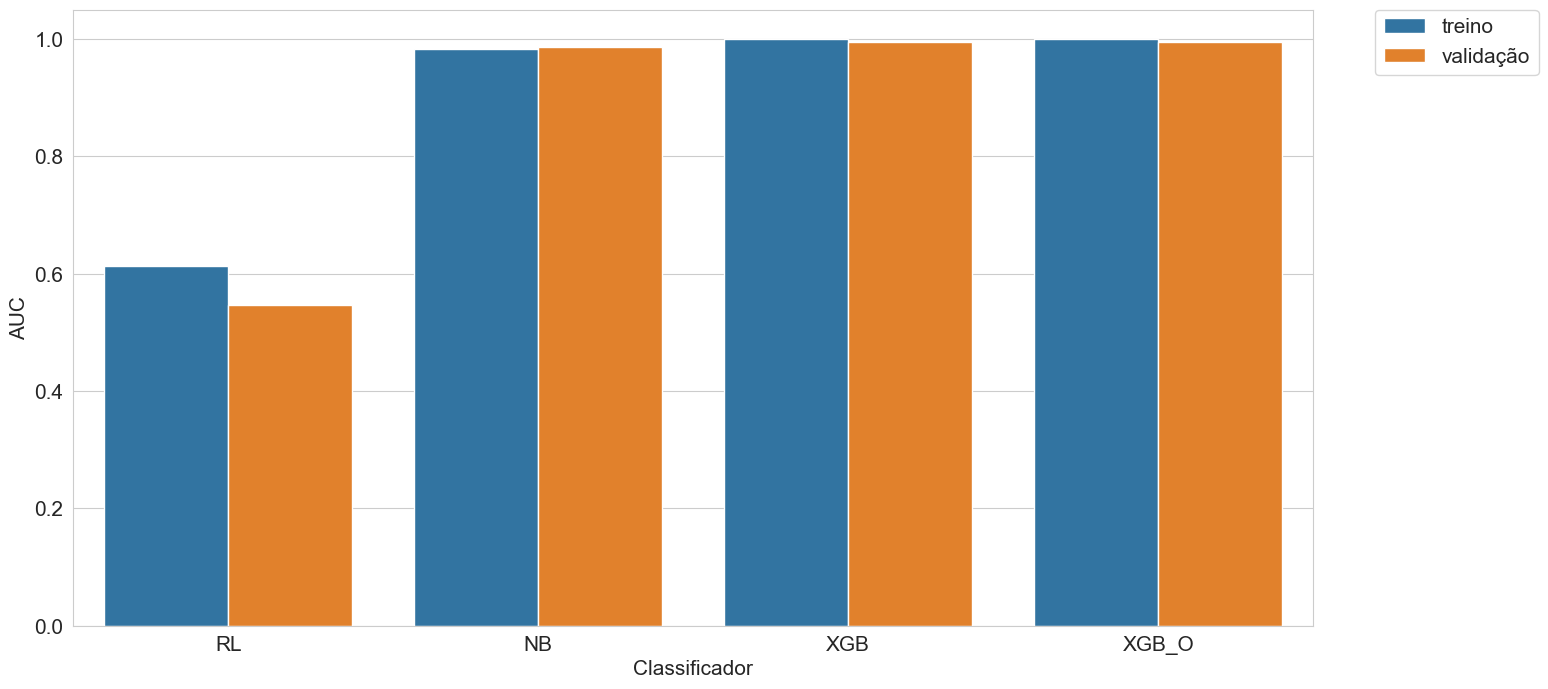

In [112]:
sns.set_style("whitegrid")
plt.figure(figsize = (16, 8))

ax = sns.barplot(x = 'classificador', y = 'auc', hue = 'data_set', data = df_results)
ax.set_xlabel('Classificador', fontsize = 15)
ax.set_ylabel('AUC', fontsize = 15)
ax.tick_params(labelsize = 15)

plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0., fontsize = 15)
plt.show();

In [113]:
print(df_results[['classificador', 'data_set', 'auc']])

  classificador   data_set       auc
0            RL     treino  0.612967
1            RL  validação  0.547044
2            NB     treino  0.982327
3            NB  validação  0.986931
4           XGB     treino  1.000000
5           XGB  validação  0.994827
6         XGB_O     treino  1.000000
7         XGB_O  validação  0.994866


In [116]:
pickle.dump(modelo_dsa_v4, open('melhor_modelo_dsa.pkl', 'wb'), protocol = 4)

In [119]:
melhor_modelo = pickle.load(open('melhor_modelo_dsa.pkl','rb'))
cols_input = pickle.load(open('cols_input.sav','rb'))
scaler = pickle.load(open('scaler.sav', 'rb'))

df_train = pd.read_csv('dados_treino.csv')
df_valid= pd.read_csv('dados_valid.csv')
df_test= pd.read_csv('dados_teste.csv')

X_train = df_train[cols_input].values
X_valid = df_valid[cols_input].values
X_test = df_test[cols_input].values

y_train = df_train['VARIAVEL_ALVO'].values
y_valid = df_valid['VARIAVEL_ALVO'].values
y_test = df_test['VARIAVEL_ALVO'].values

X_train_tf = scaler.transform(X_train)
X_valid_tf = scaler.transform(X_valid)
X_test_tf = scaler.transform(X_test)

In [120]:
y_train_preds = melhor_modelo.predict_proba(X_train_tf)[:,1]
y_valid_preds = melhor_modelo.predict_proba(X_valid_tf)[:,1]
y_test_preds = melhor_modelo.predict_proba(X_test_tf)[:,1]

In [121]:
thresh = 0.5

print('\nTreinamento:\n')
train_auc, train_accuracy, train_recall, train_precision, train_specificity = dsa_print_report(y_train,
                                                                                               y_train_preds, 
                                                                                               thresh)

print('\nValidação:\n')
valid_auc, valid_accuracy, valid_recall, valid_precision, valid_specificity = dsa_print_report(y_valid,
                                                                                               y_valid_preds, 
                                                                                               thresh)

print('\nTeste:\n')
test_auc, test_accuracy, test_recall, test_precision, test_specificity = dsa_print_report(y_test,
                                                                                          y_test_preds, 
                                                                                          thresh)


Treinamento:

AUC:0.999
Acurácia:0.981
Recall:1.000
Precisão:0.916
Especificidade:0.977
 

Validação:

AUC:0.995
Acurácia:0.970
Recall:0.961
Precisão:0.902
Especificidade:0.973
 

Teste:

AUC:0.993
Acurácia:0.965
Recall:0.934
Precisão:0.877
Especificidade:0.972
 


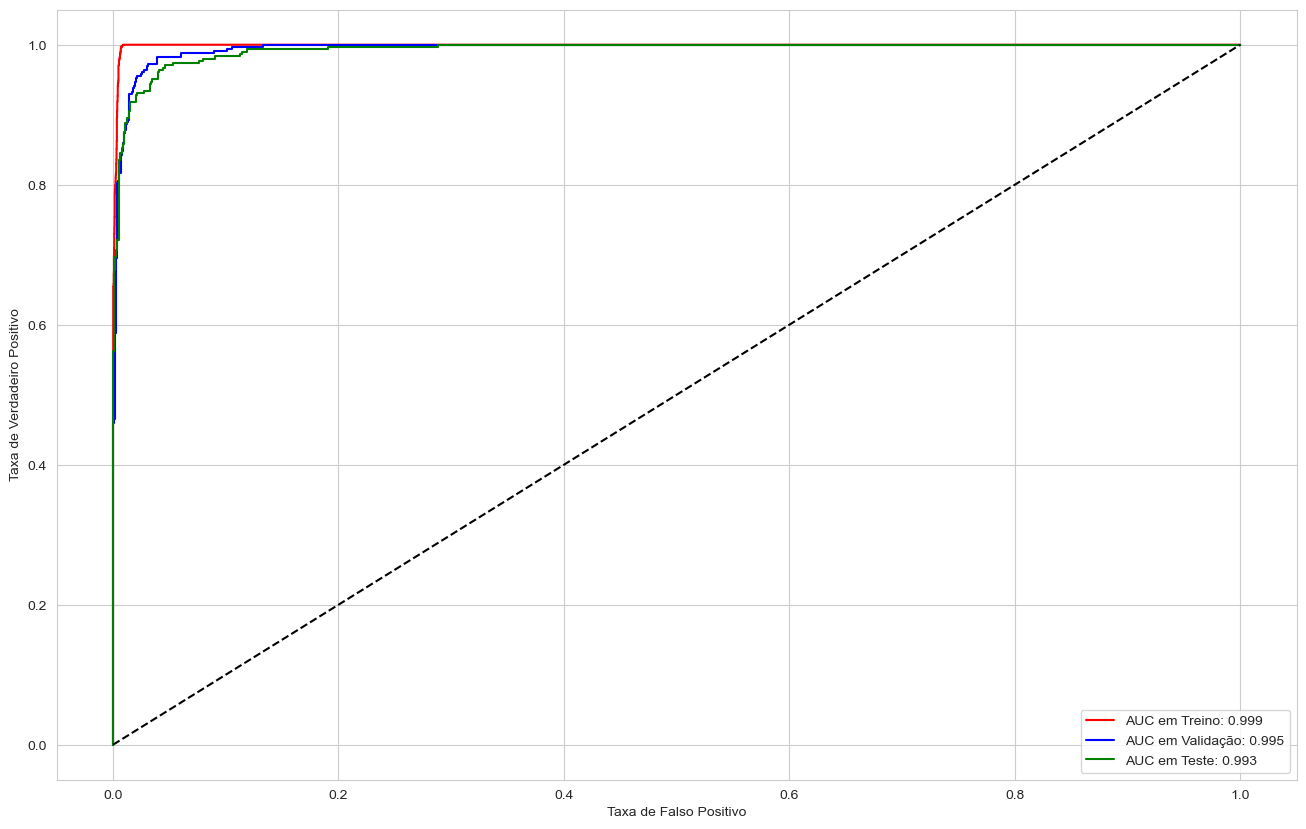

In [122]:
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_preds)
auc_train = roc_auc_score(y_train, y_train_preds)

fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, y_valid_preds)
auc_valid = roc_auc_score(y_valid, y_valid_preds)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_preds)
auc_test = roc_auc_score(y_test, y_test_preds)

plt.figure(figsize=(16,10))
plt.plot(fpr_train, tpr_train, 'r-', label = 'AUC em Treino: %.3f' % auc_train)
plt.plot(fpr_valid, tpr_valid, 'b-', label = 'AUC em Validação: %.3f' % auc_valid)
plt.plot(fpr_test, tpr_test, 'g-', label = 'AUC em Teste: %.3f' % auc_test)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.legend()
plt.show()

In [123]:
nova_maquina = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/Projetos de Machine Learning/p3/novos_dados.csv')

In [124]:
nova_maquina.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,51,43,34,21,13,12,6,4,1,-4,...,-41,-16,2,22,33,45,56,67,69,63


In [125]:
nova_maquina_scaled = scaler.transform(nova_maquina)

In [126]:
nova_maquina_scaled

array([[ 2.66820900e-01,  2.33087845e-01,  1.93313742e-01,
         1.29738916e-01,  8.43116582e-02,  6.84054944e-02,
         3.64233620e-02,  2.58030167e-02,  7.13452141e-03,
        -2.30797423e-02, -6.45020427e-02, -8.98922146e-02,
        -9.32132445e-02, -7.99979281e-02, -5.33215482e-02,
        -3.97884898e-02, -4.06567066e-02, -5.05233750e-02,
        -3.46767018e-02, -2.69632192e-02, -4.26267354e-02,
        -1.77983572e-02,  1.16505035e-02,  2.72828502e-02,
         2.34972512e-02,  2.20048057e-02,  4.48221123e-02,
         6.65413286e-02,  9.57504292e-02,  9.09785570e-02,
         7.30133495e-02,  2.07710123e-02,  7.69061161e-03,
        -7.40754929e-03,  1.69541052e-02,  4.32800795e-02,
         8.08895498e-02,  1.18794324e-01,  1.32170253e-01,
         1.62377700e-01,  1.69475621e-01,  1.84731080e-01,
         1.76246617e-01,  1.95474543e-01,  1.89999396e-01,
         1.80987874e-01,  1.68383694e-01,  1.29813011e-01,
         7.72698678e-02,  3.71188223e-02,  2.51942482e-0

In [ ]:
melhor_modelo.predict(nova_maquina_scaled)

#Resposta: A máquina não está precisando de matutenção.

array([0])